# Pecora 1998 fit comparison

Compare the five Pecora digitized SANS series and their constrained random-line fits.
This notebook follows the YYW comparison workflow, but stays focused on the Pecora
outputs produced by `cf_pecora.ipynb`.

Expected fitted series:

`salt_free` ? `10mM` ? `50mM` ? `0.5M` ? `1M`


In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA_DIR = Path("data/pecora")
OUTPUT_DIR = Path("output/pecora")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES = (
    {"key": "salt_free", "tag": "pecora_salt_free", "label": "salt-free", "color": "C0", "marker": "o", "filled": True},
    {"key": "10mM", "tag": "pecora_10mM", "label": "10 mM", "color": "C1", "marker": "o", "filled": False},
    {"key": "50mM", "tag": "pecora_50mM", "label": "50 mM", "color": "C2", "marker": "s", "filled": True},
    {"key": "0.5M", "tag": "pecora_0p5M", "label": "0.5 M", "color": "C3", "marker": "s", "filled": False},
    {"key": "1M", "tag": "pecora_1M", "label": "1 M", "color": "C4", "marker": "^", "filled": True},
)
SERIES_BY_TAG = {item["tag"]: item for item in SERIES}
SAMPLE_TAGS = tuple(item["tag"] for item in SERIES)


## Load the saved observations, fit curves, and parameters


In [29]:
def load_named_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    table = np.atleast_1d(table)
    return {str(row["name"]): float(row["value"]) for row in table}


def load_anchor_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    table = np.atleast_1d(table)
    rows = {}
    for row in table:
        rows[str(row["name"])] = {
            "value_1": float(row["value_1"]),
            "value_2": float(row["value_2"]),
            "background": float(row["background"]),
            "relative_rmse": float(row["relative_rmse"]),
        }
    return rows


observations = {
    item["tag"]: np.genfromtxt(
        OUTPUT_DIR / f"{item['tag']}_background_corrected_observation.csv",
        delimiter=",",
        names=True,
    )
    for item in SERIES
}
raw_observations = {
    item["tag"]: np.genfromtxt(
        OUTPUT_DIR / f"{item['tag']}_digitized_observation.csv",
        delimiter=",",
        names=True,
    )
    for item in SERIES
}
fit_curves = {
    item["tag"]: np.genfromtxt(
        OUTPUT_DIR / f"{item['tag']}_fit_curve.csv",
        delimiter=",",
        names=True,
    )
    for item in SERIES
}
fit_parameters = {
    item["tag"]: load_named_values(OUTPUT_DIR / f"{item['tag']}_fit_parameters.csv")
    for item in SERIES
}
anchor_guesses = {
    item["tag"]: load_anchor_values(OUTPUT_DIR / f"{item['tag']}_anchor_guesses.csv")
    for item in SERIES
}

for item in SERIES:
    tag = item["tag"]
    params = fit_parameters[tag]
    print(
        f"[status] {item['label']:>9s}: "
        f"observation points={observations[tag].size}, "
        f"fit points={fit_curves[tag].size}, "
        f"mean_k={params['mean_k']:.6g}, "
        f"k_H/k={params['k_H_over_k']:.6g}, "
        f"kappa_H={params['kappa_H']:.6g}"
    )


[status] salt-free: observation points=87, fit points=87, mean_k=0.0364224, k_H/k=0.0636376, kappa_H=0.00113698
[status]     10 mM: observation points=71, fit points=71, mean_k=0.0375364, k_H/k=0.0462988, kappa_H=0.000871944
[status]     50 mM: observation points=76, fit points=76, mean_k=0.0370368, k_H/k=0.155099, kappa_H=0.00313408
[status]     0.5 M: observation points=73, fit points=73, mean_k=0.0300002, k_H/k=0.165825, kappa_H=0.00237724
[status]       1 M: observation points=57, fit points=57, mean_k=0.030382, k_H/k=0.198554, kappa_H=0.00290436


## Digitized curves and model fits on one plot


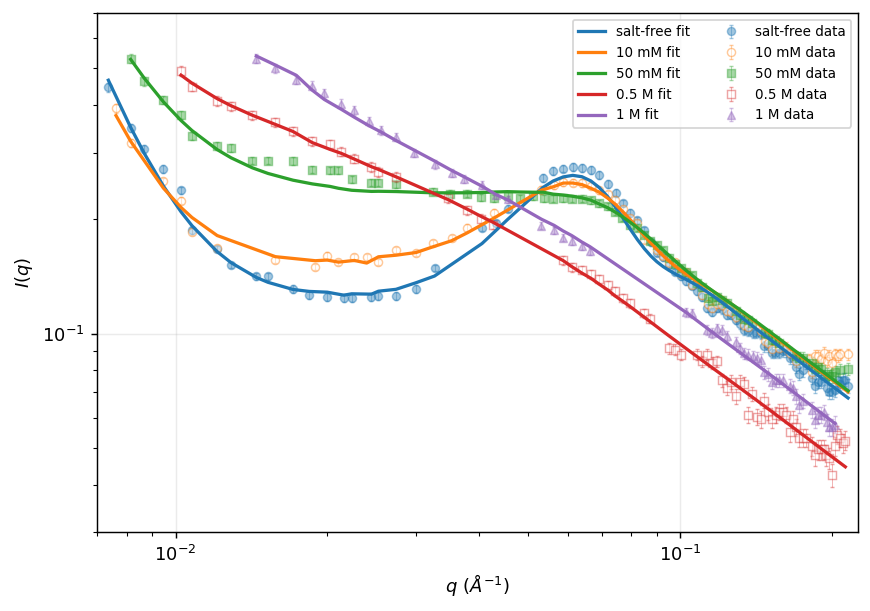

[status] saved output\pecora\pecora_all_observations_and_model_fits.png


In [30]:
fig, ax = plt.subplots(figsize=(6.8, 4.8))

for item in SERIES:
    tag = item["tag"]
    obs = observations[tag]
    fit = fit_curves[tag]
    positive = np.isfinite(obs["I"]) & (obs["I"] > 0.0)
    marker_face = item["color"] if item["filled"] else "white"
    ax.errorbar(
        obs["Q"][positive],
        obs["I"][positive],
        yerr=obs["err"][positive],
        fmt=item["marker"],
        ms=4.5,
        lw=0.45,
        capsize=1.2,
        color=item["color"],
        markerfacecolor=marker_face,
        markeredgewidth=0.8,
        alpha=0.42,
        label=f"{item['label']} data",
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"],
        color=item["color"],
        lw=1.8,
        label=f"{item['label']} fit",
        zorder=10,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(7.0e-3, 2.25e-1)
ax.set_ylim(3.0e-2, 7.0e-1)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout()

COMPARISON_PLOT = OUTPUT_DIR / "pecora_all_observations_and_model_fits.png"
fig.savefig(COMPARISON_PLOT, bbox_inches="tight")
plt.show()
print(f"[status] saved {COMPARISON_PLOT}")


## Fit-parameter summary


In [31]:
FLOATING_PARAMETER_NAMES = (
    "mean_k", "r_sigma_k", "skewness", "k_H_over_k", "b", "scale"
)
DERIVED_PARAMETER_NAMES = (
    "k_H", "p_H", "sigma_H_squared", "alpha_H", "kappa_H", "rho0", "highq_coefficient"
)

print("Pecora fit information map")
print("-" * 108)
print("Floating: " + ", ".join(FLOATING_PARAMETER_NAMES))
print("Derived:  " + ", ".join(DERIVED_PARAMETER_NAMES))
print("-" * 108)
for item in SERIES:
    tag = item["tag"]
    params = fit_parameters[tag]
    anchors = anchor_guesses[tag]
    n_fit = len(fit_curves[tag]["Q"])
    highq_anchor = anchors["highQ_line"]["value_1"]
    lowq_kappa = anchors["lowQ_DAB"]["value_1"]
    print(
        f"{item['label']:>9s}: N_fit={n_fit}, effective fit parameters=6, "
        f"nominal residual dof={n_fit-6}"
    )
    print(
        f"  mean_k={params['mean_k']:.6g}, r_sigma_k={params['r_sigma_k']:.6g}, "
        f"skewness={params['skewness']:.6g}, k_H/k={params['k_H_over_k']:.6g}, "
        f"b={params['b']:.6g}, scale={params['scale']:.6g}"
    )
    print(
        f"  kappa_H={params['kappa_H']:.6g}; low-q DAB anchor kappa={lowq_kappa:.6g}; "
        f"model/anchor={params['kappa_H']/lowq_kappa:.6g}"
    )
    print(
        f"  high-q coefficient model={params['highq_coefficient']:.6g}; "
        f"anchor={highq_anchor:.6g}; model/anchor={params['highq_coefficient']/highq_anchor:.6g}"
    )


Pecora fit information map
------------------------------------------------------------------------------------------------------------
Floating: mean_k, r_sigma_k, skewness, k_H_over_k, b, scale
Derived:  k_H, p_H, sigma_H_squared, alpha_H, kappa_H, rho0, highq_coefficient
------------------------------------------------------------------------------------------------------------
salt-free: N_fit=87, effective fit parameters=6, nominal residual dof=81
  mean_k=0.0364224, r_sigma_k=0.208111, skewness=0.256271, k_H/k=0.0636376, b=-1.58249, scale=32.9078
  kappa_H=0.00113698; low-q DAB anchor kappa=0.006; model/anchor=0.189497
  high-q coefficient model=0.014313; anchor=0.0138959; model/anchor=1.03002
    10 mM: N_fit=71, effective fit parameters=6, nominal residual dof=65
  mean_k=0.0375364, r_sigma_k=0.265961, skewness=0.262334, k_H/k=0.0462988, b=-1.6559, scale=31.0632
  kappa_H=0.000871944; low-q DAB anchor kappa=0.006; model/anchor=0.145324
  high-q coefficient model=0.0148471; anch

## Display all fitted curves on the Pecora 1998 figure

The overlay uses the same linear axis calibration as `data/pecora/digitize_pecora.py`.
The scan is cropped to the printed plot frame and shown in physical `(q, I)` coordinates,
so the fitted curves can be drawn directly on top.


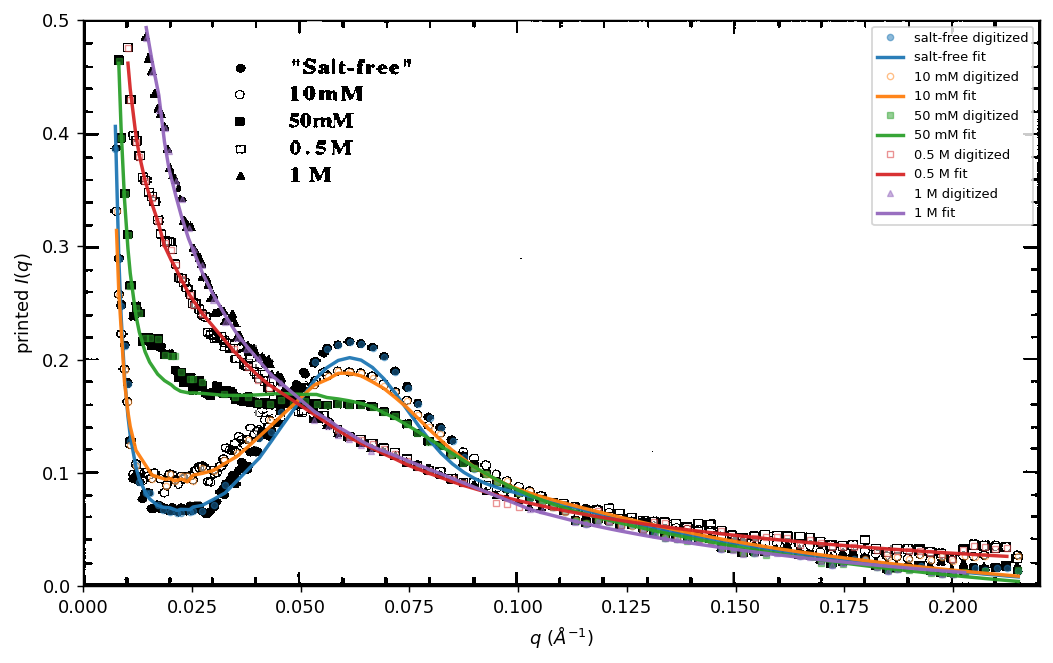

[status] saved output\pecora\pecora_1998_figure_with_all_fits.png


In [32]:
# Axis calibration copied from data/pecora/digitize_pecora.py.
X_LEFT, X_RIGHT = 174.0, 1011.0
Y_TOP, Y_BOTTOM = 125.0, 684.0
Q_MIN, Q_MAX = 0.0, 0.22
I_MIN, I_MAX = 0.0, 0.50

figure_image = plt.imread(DATA_DIR / "pecora_1998_figure.png")
crop = figure_image[int(Y_TOP): int(Y_BOTTOM) + 1, int(X_LEFT): int(X_RIGHT) + 1]

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.imshow(
    crop,
    extent=(Q_MIN, Q_MAX, I_MIN, I_MAX),
    origin="upper",
    aspect="auto",
    interpolation="nearest",
    zorder=0,
)

# Raw digitized points sit in the coordinate system of the printed figure.
# The fitted curves are from the background-corrected data; add back the
# subtracted constant background so they sit on the original printed figure.
for item in SERIES:
    tag = item["tag"]
    raw = raw_observations[tag]
    fit = fit_curves[tag]
    anchors = anchor_guesses[tag]
    background = anchors["subtracted_background"]["value_1"]
    marker_face = item["color"] if item["filled"] else "white"

    ax.plot(
        raw["Q"],
        raw["I"],
        linestyle="none",
        marker=item["marker"],
        markersize=3.5,
        markerfacecolor=marker_face,
        markeredgecolor=item["color"],
        markeredgewidth=0.75,
        alpha=0.50,
        label=f"{item['label']} digitized",
        zorder=4,
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"] + background,
        color=item["color"],
        lw=1.9,
        alpha=0.95,
        label=f"{item['label']} fit",
        zorder=8,
    )

ax.set_xlim(Q_MIN, Q_MAX)
ax.set_ylim(I_MIN, I_MAX)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"printed $I(q)$")
ax.grid(False)
ax.legend(loc="upper right", fontsize=7.2, frameon=True, ncol=1)
fig.tight_layout()

FIGURE_OVERLAY = OUTPUT_DIR / "pecora_1998_figure_with_all_fits.png"
fig.savefig(FIGURE_OVERLAY, bbox_inches="tight")
plt.show()
print(f"[status] saved {FIGURE_OVERLAY}")
